In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

# Saída de um sistema

Considere o sistema:

\begin{align}
	y\left[n+2\right] - y\left[n+1\right] + 0.24 y\left[n\right] = x\left[n+2\right] - 2 x\left[n+1\right]
\end{align}

E considere que: 

\begin{align}
	y\left[-1\right] &= 2 \\
	y\left[-2\right] &= 1 \\
	x\left[n\right] &= n~u\left[n\right] 
\end{align}

Escreva um código python para determinar a saída para $n = -2 \ldots 10$. 

In [2]:
#Definindo uma função para o degrau unitário
def u(n):
    y = np.ones_like(n, dtype=float)
    y[n < 0] = 0
    return y
    

In [3]:
#Crio as variáveis primeiro
n = np.arange(-2, 11, 1)
x = n * u(n)

y = np.zeros_like(n, dtype=float)
y[n == -2] = 1
y[n == -1] = 2

for k in range(2,len(n)):
    y[k] = -0.24 * y[k-2] + y[k-1] + x[k] - 2 * x[k-1]
    
print(f'n = {n}')
print(f'x = {x}')
print(f'y = {y}')

n = [-2 -1  0  1  2  3  4  5  6  7  8  9 10]
x = [-0. -0.  0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
y = [  1.           2.           1.76         2.28         1.8576
   0.3104      -2.135424    -5.20992     -8.69741824 -12.44703744
 -16.35965706 -20.37236808 -24.44605038]


# Exemplo 1:

\begin{align}
	y\left[n+2\right] - 0.6 y\left[n+1\right] - 0.16 y\left[n\right] = 5 x\left[n+2\right]
\end{align}

E considere que: 

\begin{align}
	y\left[-1\right] &= 0 \\
	y\left[-2\right] &= \frac{25}{4}	
\end{align}

Determine a resposta de entrada nula. 

<StemContainer object of 3 artists>

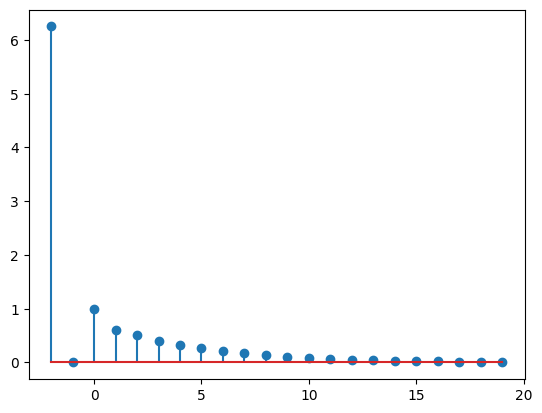

In [5]:
#Crio as variáveis primeiro
n1 = np.arange(-2, 20, 1)

y1 = np.zeros_like(n1, dtype=float)
y1[n1 == -2] = 25/4
y1[n1 == -1] = 0

for k in range(2,len(n1)):
    y1[k] = 0.16 * y1[k-2] + 0.6 * y1[k-1]
    
plt.stem(n1, y1)

Vimos em sala de aula que a resposta deste sistema é:

\begin{align}
	y_0\left[n\right] = 0.8 \cdot \left(0.8\right)^n + 0.2 \cdot \left(-0.2 \right)n
\end{align}

Recursiva | Fechada
6.250000  |  6.250000
0.000000  |  0.000000
1.000000  |  1.000000
0.600000  |  0.600000
0.520000  |  0.520000
0.408000  |  0.408000
0.328000  |  0.328000
0.262080  |  0.262080
0.209728  |  0.209728
0.167770  |  0.167770
0.134218  |  0.134218
0.107374  |  0.107374
0.085899  |  0.085899


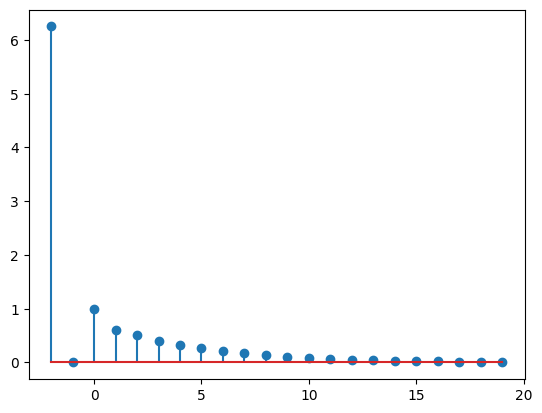

In [6]:
y10 = np.zeros_like(n1, dtype=float)

y10 = 0.8 * (0.8) ** n1 + 0.2 * (-0.2) ** n1
y10[0] = 25/4
y10[1] = 0

plt.stem(n1, y10)

print(f'Recursiva | Fechada')
for k in range(len(n)):
    print(f'{y1[k]:.6f}  |  {y10[k]:.6f}')

# Exemplo 2:

\begin{align}
	y\left[n+2\right] + 6 y\left[n+1\right] + 9 y\left[n\right] = 2 x\left[n+2\right] + 6 x\left[n+1\right]
\end{align}

E considere que: 

\begin{align}
	y\left[-1\right] &= -\frac{1}{3} \\
	y\left[-2\right] &= -\frac{2}{9}	
\end{align}

Determine a resposta de entrada nula. 

<StemContainer object of 3 artists>

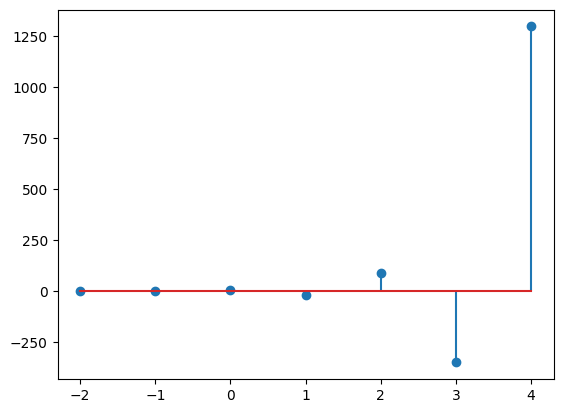

In [7]:
#Crio as variáveis primeiro
n2 = np.arange(0, 5, 1)

y2 = np.zeros_like(n2, dtype=float)
condicao_inicial = np.array([-2/9, -1/3])

y2 = np.concatenate((condicao_inicial, y2))

n2 = np.arange(-2, 5, 1)
for k in range(2,len(n2)):
    y2[k] = - 9 * y2[k-2] - 6 * y2[k-1]
    
plt.stem(n2, y2)

[-2.22222222e-01 -3.33333333e-01  4.00000000e+00 -2.10000000e+01
  9.00000000e+01 -3.51000000e+02  1.29600000e+03]
Recursiva | Fechada
-0.222222  |  -0.222222
-0.333333  |  -0.333333
4.000000  |  4.000000
-21.000000  |  -21.000000
90.000000  |  90.000000
-351.000000  |  -351.000000
1296.000000  |  1296.000000


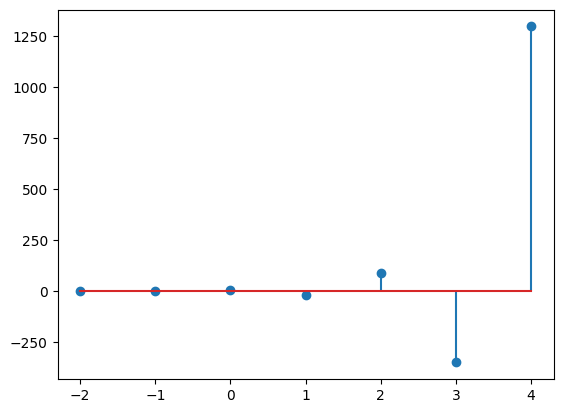

In [8]:
n2 = np.arange(0, 5, 1)
y20 = np.zeros_like(n2, dtype=float)

y20 = (4 + 3 * n2) * (-3) ** n2

condicao_inicial = np.array([-2/9, -1/3])
y20 = np.concatenate((condicao_inicial, y20))

print(y20)

n2 = np.arange(-2, 5, 1)
plt.stem(n2, y20)

print(f'Recursiva | Fechada')
for k in range(len(n2)):
    print(f'{y2[k]:.6f}  |  {y20[k]:.6f}')

# Exemplo 3:

\begin{align}
	y\left[n+2\right] - 1.56 y\left[n+1\right] + 0.81 y\left[n\right] = x\left[n+1\right] + 3 x\left[n\right]
\end{align}

E considere que: 

\begin{align}
	y\left[-1\right] &= 2 \\
	y\left[-2\right] &= 1	
\end{align}

Determine a resposta de entrada nula. 

<StemContainer object of 3 artists>

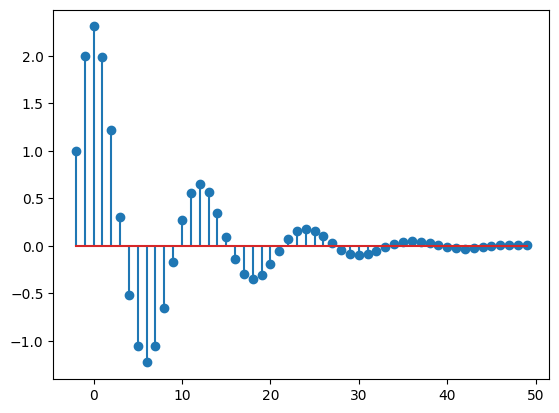

In [9]:
#Crio as variáveis primeiro
n3 = np.arange(0, 50, 1)

y3 = np.zeros_like(n3, dtype=float)
condicao_inicial = np.array([1 , 2], dtype=float)

y3 = np.concatenate((condicao_inicial, y3))

n3 = np.arange(-2, 50, 1)
for k in range(2,len(n3)):
    y3[k] = - 0.81 * y3[k-2] + 1.56 * y3[k-1]
    
plt.stem(n3, y3)

2.3428807054564262
-0.1702710801594384
Recursiva | Fechada
1.000000  |  1.000000
2.000000  |  2.000000
2.310000  |  2.309000
1.983600  |  1.978337
1.223316  |  1.213633
0.301657  |  0.289413
-0.520301  |  -0.531892
-1.056012  |  -1.063563
-1.225935  |  -1.227097
-1.057088  |  -1.051370
-0.656051  |  -0.644974
-0.167198  |  -0.153806
0.270573  |  0.282669
0.557524  |  0.565221
0.650573  |  0.652130
0.563300  |  0.558741
0.351783  |  0.342766
0.092509  |  0.081739
-0.140630  |  -0.150222
-0.294315  |  -0.300382
-0.345222  |  -0.346569
-0.300150  |  -0.296938
-0.188605  |  -0.182160
-0.051102  |  -0.043439
0.073051  |  0.079834
0.155352  |  0.159635
0.183178  |  0.184181
0.159922  |  0.157805
0.101105  |  0.096807
0.028186  |  0.023085
-0.037924  |  -0.042427
-0.081993  |  -0.084837
-0.097190  |  -0.097881
-0.085202  |  -0.083864
-0.054192  |  -0.051447
-0.015525  |  -0.012269
0.019676  |  0.022548
0.043270  |  0.045086
0.051564  |  0.052018
0.045391  |  0.044569
0.029043  |  0.027341
0.0

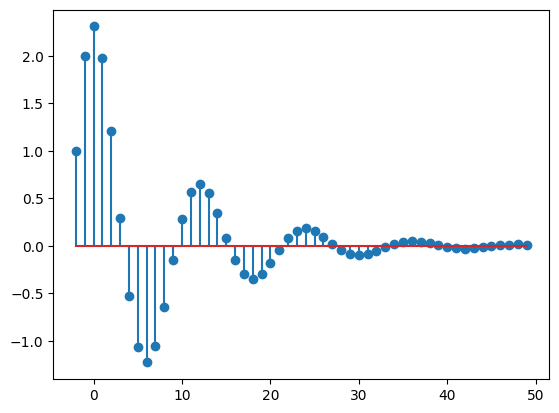

In [11]:
n3 = np.arange(0, 50, 1)
y30 = np.zeros_like(n3, dtype=float)

theta = np.arctan(-0.397/2.309)
c = 2.309 / np.cos(theta)

print(c)
print(theta)

y30 = c * ((0.9) ** n3) * np.cos ((np.pi/6) * n3 + theta)

condicao_inicial = np.array([1, 2],dtype=float)
y30 = np.concatenate((condicao_inicial, y30))

n3 = np.arange(-2, 50, 1)
plt.stem(n3, y30)

print(f'Recursiva | Fechada')
for k in range(len(n3)):
    print(f'{y3[k]:.6f}  |  {y30[k]:.6f}')